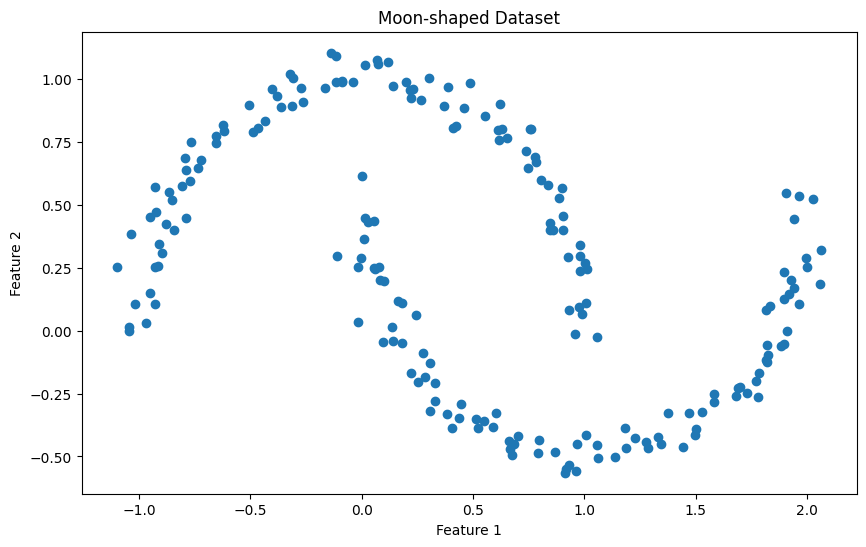

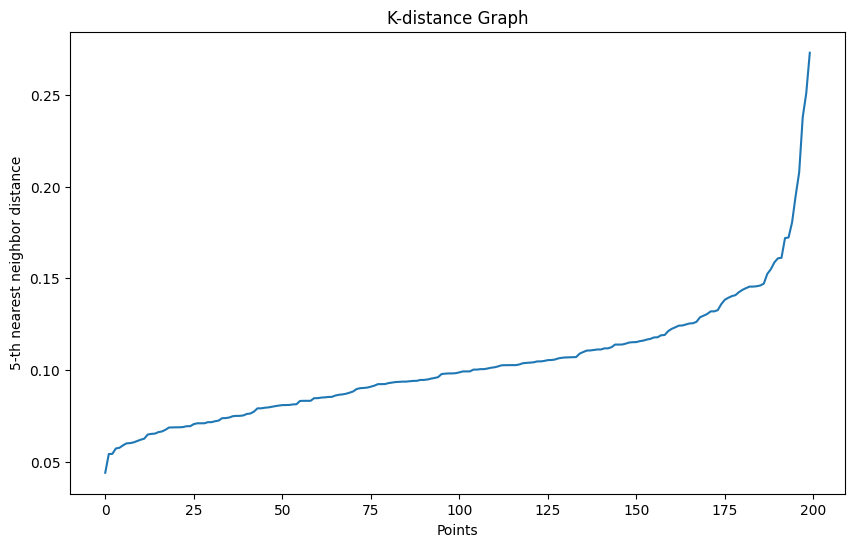

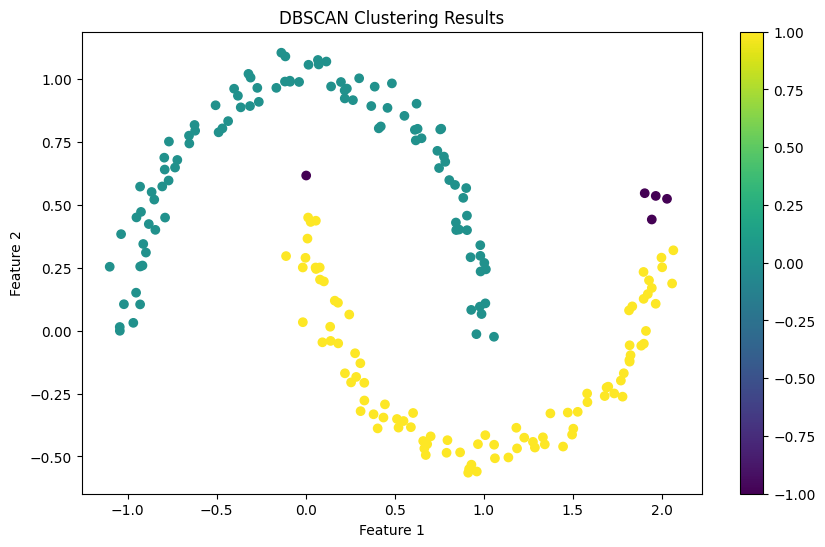

Number of clusters: 2
Number of noise points: 5


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

# Perform DBSCAN clustering
epsilon = 0.15  # Chosen based on k-distance graph
min_samples = 5  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(X)

# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')



Cluster Labels:
[ 0  0  0  1  1  1  2  2  2 -1 -1]


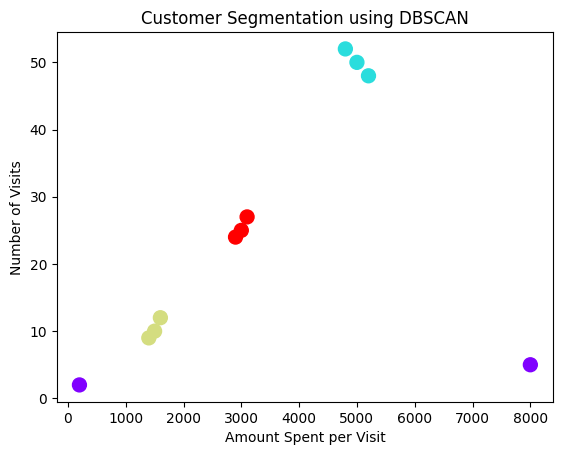

In [7]:
"""Scenario: Customer Segmentation for a Retail Store
Context:
A retail store wants to understand its customers better. 
They have data on how much each customer spends per visit and how frequently they visit the store. 
The goal is to group customers into clusters (e.g., “loyal high spenders,” “occasional visitors,” etc.) using DBSCAN,
which is great for finding clusters of varying shapes and identifying outliers."""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Customer data: [Amount Spent, Number of Visits]
data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier
    [200, 2],                             # Outlier
])

# Apply DBSCAN
db = DBSCAN(eps=500, min_samples=2)
labels = db.fit_predict(data)

# Print cluster labels
print("Cluster Labels:")
print(labels)

# Plot clusters
plt.scatter(data[:,0], data[:,1], c=labels, cmap="rainbow", s=100)

plt.title("Customer Segmentation using DBSCAN")
plt.xlabel("Amount Spent per Visit")
plt.ylabel("Number of Visits")

plt.show()

In [9]:
"""
Scenario: Fine‑tune ResNet‑50 for Music Genre Classification
Context:
A streaming service wants to automatically classify songs into genres (e.g., rock, jazz, classical, hip‑hop, electronic). They have 4,000 audio tracks labeled by genre. Instead of training from scratch, they’ll fine‑tune a ResNet‑50 pretrained on ImageNet, but adapted to work with spectrogram images of audio.

📊 Dataset
- Convert each audio track into a Mel‑spectrogram (visual representation of sound frequencies over time).
- Each spectrogram is treated like an image (RGB channels).
- Dataset: 4,000 spectrograms across 5 genres.
"""
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load pretrained ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

# Add new classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Data preprocessing
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    "spectrogram_dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "spectrogram_dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Train model
model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# Fine-tuning last layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again with fine-tuning
model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'spectrogram_dataset'

In [11]:
"""🎯 Scenario: Medical Image Classification
You’re training a convolutional neural network (CNN) to detect pneumonia from chest X-rays.
- Training accuracy: 95%
- Validation accuracy: 74%
At first glance, the model seems powerful — it almost perfectly classifies the training set. But the sharp drop in validation accuracy signals overfitting: the network has memorized the training images (specific pixel patterns, noise, or even hospital-specific artifacts) instead of learning generalizable features of pneumonia.

⚙️ Levers to Address Overfitting
- Data Augmentation: Rotate, flip, and adjust brightness of X-rays to simulate variability.
- Regularization: Apply dropout in dense layers or L2 weight decay.
- Transfer Learning: Use a pretrained backbone (e.g., ResNet) to leverage generalized features.
- Cross-validation: Ensure robustness across different patient subsets.
- Early Stopping: Halt training when validation loss stops improving.
"""
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# -----------------------------
# 1. Create our own dataset
# -----------------------------

# 4000 images (simulated chest X-rays)
X = np.random.rand(4000,224,224,3)

# Labels: 0 = Normal, 1 = Pneumonia
y = np.random.randint(0,2,4000)

# Split dataset
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# -----------------------------
# 2. Load pretrained ResNet50
# -----------------------------

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable=False

# -----------------------------
# 3. Add custom classifier
# -----------------------------

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256,activation='relu',kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(1,activation='sigmoid')(x)

model = Model(inputs=base_model.input,outputs=output)

# -----------------------------
# 4. Compile model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# 5. Early stopping
# -----------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# 6. Train model
# -----------------------------

model.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.4984 - loss: 0.8321 - val_accuracy: 0.5013 - val_loss: 0.7261
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.4913 - loss: 0.7230 - val_accuracy: 0.4988 - val_loss: 0.7102
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.4928 - loss: 0.7093 - val_accuracy: 0.5013 - val_loss: 0.7051
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.5181 - loss: 0.7035 - val_accuracy: 0.4988 - val_loss: 0.7021
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.5097 - loss: 0.7018 - val_accuracy: 0.5013 - val_loss: 0.7002
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.4969 - loss: 0.7001 - val_accuracy: 0.5013 - val_loss: 0.6989
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - accuracy: 0.5075 - loss: 0.6990 - val_accuracy: 0.5013 - val_loss: 0.6985
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.5100 - loss: 0.6994 - val_accu